In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

%matplotlib inline

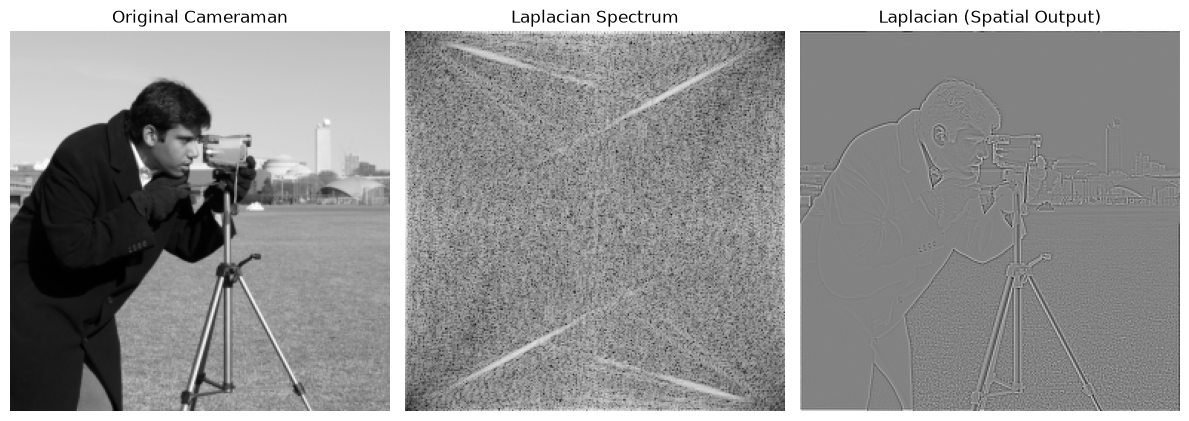

In [2]:
image = data.camera()
image = resize(image, (256, 256))

M, N = image.shape

u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

F = np.fft.fft2(image)

F_lap = F * laplacian_filter

laplacian_image = np.fft.ifft2(F_lap).real

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)'); plt.axis('off')

plt.tight_layout(); plt.show()

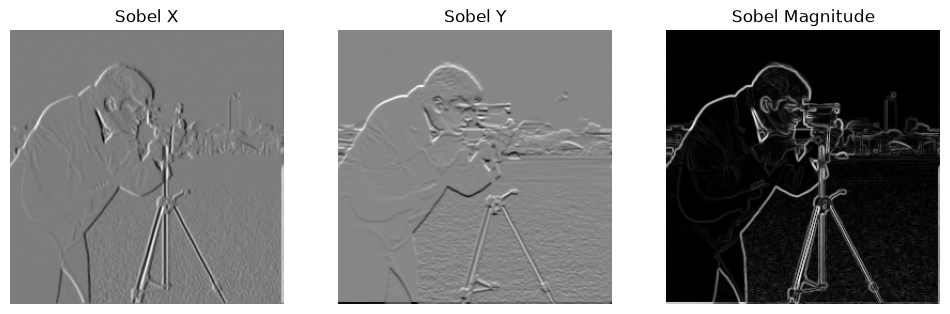

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

img = data.camera()
img = resize(img, (256, 256))

def center_embed_kernel(kernel, target_shape):
    kh, kw = kernel.shape
    padded = np.zeros(target_shape)
    r_start = (target_shape[0] - kh) // 2
    c_start = (target_shape[1] - kw) // 2
    padded[r_start:r_start+kh, c_start:c_start+kw] = kernel
    return np.fft.fft2(np.fft.ifftshift(padded))

sobel_x = np.array([[-1, 0, 1], 
                    [-2, 0, 2], 
                    [-1, 0, 1]], dtype=float)

sobel_y = np.array([[-1, -2, -1], 
                    [ 0,  0,  0], 
                    [ 1,  2,  1]], dtype=float)

H_x = center_embed_kernel(sobel_x, img.shape)
H_y = center_embed_kernel(sobel_y, img.shape)

F = np.fft.fft2(img)

G_x = F * H_x
G_y = F * H_y

img_x = np.real(np.fft.ifft2(G_x))
img_y = np.real(np.fft.ifft2(G_y))

sobel_magnitude = np.sqrt(img_x**2 + img_y**2)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_x, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_y, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')

plt.show()